# Lecture 7 — Class Exercise_ Dennis Sebastian
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv(r"C:\Users\denni\Downloads\netflix_catalogue.csv")

print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())

Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [3]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())

Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade

In [4]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')


In [5]:
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'



In [6]:
ratings = ["TV-14", "TV-MA", "PG-13", "R", "PG"]
df_filtered = df[df['rating'].isin(ratings)]



In [7]:
heatmap_data = (
    df_filtered
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

In [8]:
pivot = heatmap_data.pivot(index='rating', columns='decade', values='count').fillna(0)

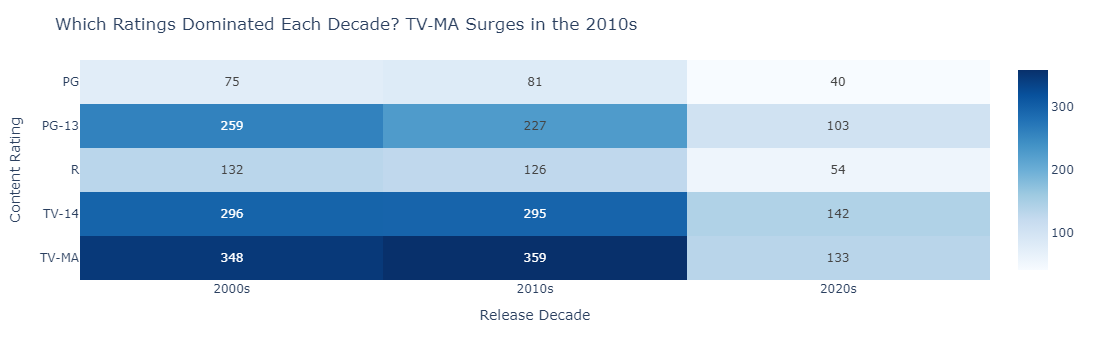

In [9]:
fig = px.imshow(
    pivot,
    color_continuous_scale='Blues',
    text_auto=True,
    aspect='auto'
)

fig.update_layout(
    title="Which Ratings Dominated Each Decade? TV‑MA Surges in the 2010s",
    xaxis_title="Release Decade",
    yaxis_title="Content Rating"
)

fig.show()


TV‑MA explodes in the 2010s, becoming the dominant rating as streaming platforms scale up.

**Task 2 — Waterfall: Movie vs TV Show additions by year**

What to build: A waterfall chart showing how Netflix's Movie library grew year by year (2015-2022).

Requirements:

Filter to Movies only
Group by added_year, count titles per year
Final bar should be the cumulative total
Green bars (additions), blue total
Annotation on the year with the largest single addition
Insight title naming the growth story

In [12]:
movies = df[df['type'] == 'Movie']

In [13]:
yearly = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='count')
    .sort_values('added_year')
)

In [14]:
yearly['cumulative'] = yearly['count'].cumsum()

In [15]:
max_year = yearly.loc[yearly['count'].idxmax(), 'added_year']
max_value = yearly['count'].max()

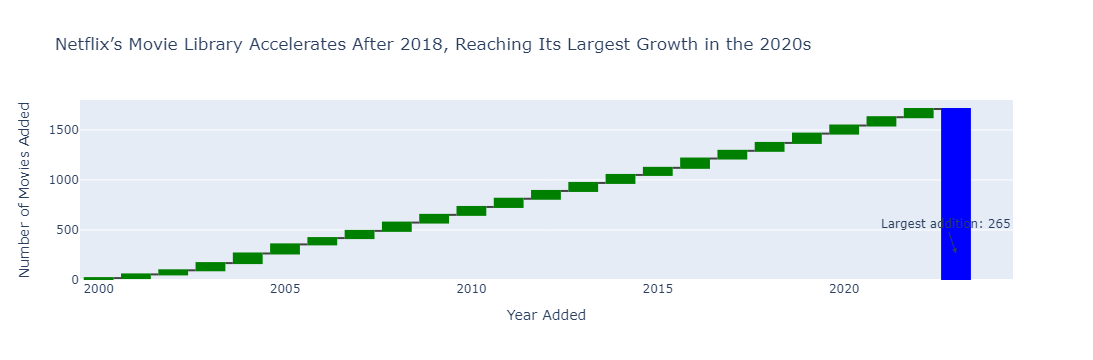

In [16]:
fig = go.Figure()

# Add yearly bars (green)
fig.add_trace(go.Waterfall(
    name="Yearly Additions",
    orientation="v",
    x=yearly['added_year'],
    y=yearly['count'],
    increasing={"marker": {"color": "green"}},
    decreasing={"marker": {"color": "green"}},
    totals={"marker": {"color": "blue"}},
    measure=["relative"] * (len(yearly) - 1) + ["total"]
))

# Annotation for largest addition
fig.add_annotation(
    x=max_year,
    y=max_value,
    text=f"Largest addition: {max_value}",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    title="Netflix’s Movie Library Accelerates After 2018, Reaching Its Largest Growth in the 2020s",
    xaxis_title="Year Added",
    yaxis_title="Number of Movies Added"
)

fig.show()